# Phase 5: Short-Term SST Forecasting

This notebook builds machine learning models to forecast California coast regional mean SST 7 days ahead.

Models compared:

- Persistence baseline
- Linear Regression
- Random Forest
- XGBoost

Validation strategy:

- Chronological train/test split
- TimeSeriesSplit cross-validation

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.features import create_forecast_features, get_feature_columns
from src.modeling import (
    temporal_train_test_split,
    persistence_forecast,
    train_linear_regression,
    train_random_forest,
    train_xgboost,
    time_series_cv_scores,
)
from src.evaluation import evaluate_regression, make_metrics_table

In [2]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

DAILY_PATH = PROCESSED_DIR / "mhw_daily_labeled_1982_2024.csv"
ONI_PATH = PROCESSED_DIR / "oni_monthly.csv"

daily = pd.read_csv(DAILY_PATH)
oni = pd.read_csv(ONI_PATH)

daily["date"] = pd.to_datetime(daily["date"])
oni["date"] = pd.to_datetime(oni["date"])

daily.head()


,date,year,sst,day_of_year,climatological_mean,threshold,sst_anomaly,threshold_anomaly,above_threshold,mhw_event_id
0,1982-01-01,1982,14.619334,1,14.419488,15.299240,0.199846,0.879752,False,NaN
1,1982-01-02,1982,14.521364,2,14.419681,15.192833,0.101683,0.773153,False,NaN
2,1982-01-03,1982,14.399932,3,14.427253,15.185508,-0.027321,0.758255,False,NaN
3,1982-01-04,1982,14.327671,4,14.422400,15.201450,-0.094729,0.779050,False,NaN
4,1982-01-05,1982,14.418211,5,14.389955,15.262431,0.028256,0.872476,False,NaN


In [3]:
oni_daily = oni[["date", "oni", "enso_phase"]].copy()
oni_daily = oni_daily.set_index("date").resample("D").ffill().reset_index()

model_df = daily.merge(oni_daily[["date", "oni"]], on="date", how="left")

model_df["oni"] = model_df["oni"].ffill().bfill()

model_df.head()


,date,year,sst,day_of_year,climatological_mean,threshold,sst_anomaly,threshold_anomaly,above_threshold,mhw_event_id,oni
0,1982-01-01,1982,14.619334,1,14.419488,15.299240,0.199846,0.879752,False,NaN,-0.05
1,1982-01-02,1982,14.521364,2,14.419681,15.192833,0.101683,0.773153,False,NaN,-0.05
2,1982-01-03,1982,14.399932,3,14.427253,15.185508,-0.027321,0.758255,False,NaN,-0.05
3,1982-01-04,1982,14.327671,4,14.422400,15.201450,-0.094729,0.779050,False,NaN,-0.05
4,1982-01-05,1982,14.418211,5,14.389955,15.262431,0.028256,0.872476,False,NaN,-0.05


In [4]:
# 建特征
forecast_df = create_forecast_features(model_df, horizon_days=7)

feature_cols = get_feature_columns()
target_col = "target_sst_7d_ahead"

print("Forecast dataset shape:", forecast_df.shape)
forecast_df[["date", "sst", target_col] + feature_cols[:5]].head()

Forecast dataset shape: (2222, 26)


,date,sst,target_sst_7d_ahead,month,sin_day,cos_day,sst_lag_1,sst_lag_2
0,1982-12-22,15.837225,14.875630,12,-0.158452,0.987367,15.581503,15.456077
1,1982-12-23,15.895217,14.820905,12,-0.141444,0.989946,15.837225,15.581503
2,1982-12-24,15.652361,14.750756,12,-0.124395,0.992233,15.895217,15.837225
3,1982-12-25,15.669850,14.783531,12,-0.107308,0.994226,15.652361,15.895217
4,1982-12-26,15.615068,15.050470,12,-0.090190,0.995925,15.669850,15.652361


In [5]:
print("Date range:")
print(forecast_df["date"].min(), "to", forecast_df["date"].max())

print("\nMissing values:")
print(forecast_df[feature_cols + [target_col]].isna().sum())

forecast_df[[target_col] + feature_cols].describe()


Date range:
1982-12-22 00:00:00 to 2024-09-12 00:00:00

Missing values:
month                  0
sin_day                0
cos_day                0
sst_lag_1              0
sst_lag_2              0
sst_lag_3              0
sst_lag_7              0
sst_lag_14             0
sst_lag_30             0
sst_roll_mean_7        0
sst_roll_mean_30       0
sst_roll_std_7         0
oni_lag_1              0
sst_anomaly_lag_1      0
target_sst_7d_ahead    0
dtype: int64


,target_sst_7d_ahead,month,sin_day,cos_day,sst_lag_1,sst_lag_2,sst_lag_3,sst_lag_7,sst_lag_14,sst_lag_30,sst_roll_mean_7,sst_roll_mean_30,sst_roll_std_7,oni_lag_1,sst_anomaly_lag_1
count,2222.000000,2222.000000,2222.000000,2222.000000,2222.000000,2222.000000,2222.000000,2222.000000,2222.000000,2222.000000,2222.000000,2222.000000,2222.000000,2222.000000,2222.000000
mean,17.170785,7.030603,-0.146814,0.070823,17.296614,17.283191,17.267265,17.212159,17.141181,17.048088,17.253314,17.144448,0.168069,0.700275,1.402422
std,1.672433,3.528868,0.713449,0.681806,1.635612,1.640203,1.644286,1.653813,1.685057,1.689443,1.636467,1.625796,0.101407,1.109079,0.473837
min,14.423957,1.000000,-0.999999,-0.999979,14.443704,14.332521,14.332521,14.221283,13.824288,13.393371,14.451222,14.133203,0.008050,-1.200000,0.245614
25%,15.618417,4.000000,-0.833183,-0.578702,15.720407,15.712462,15.707167,15.679312,15.593637,15.568921,15.694349,15.610281,0.093144,-0.240000,1.057365
50%,17.007300,8.000000,-0.325128,0.121193,17.141072,17.148204,17.149856,17.155769,17.134145,17.061227,17.156995,17.129093,0.143978,0.650000,1.287623
75%,18.698911,10.000000,0.572983,0.750154,18.785345,18.764571,18.748085,18.675990,18.600086,18.413811,18.727767,18.581972,0.219637,1.710000,1.662486
max,20.819645,12.000000,0.999986,0.999991,20.819645,20.819645,20.819645,20.819645,20.819645,20.819645,20.554431,20.276066,0.631973,2.750000,3.227449


In [6]:
# 时间序列训练/测试切分
test_start_date = "2018-01-01"

train_df, test_df = temporal_train_test_split(
    forecast_df, test_start_date=test_start_date
)

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train:", train_df["date"].min(), "to", train_df["date"].max(), train_df.shape)
print("Test :", test_df["date"].min(), "to", test_df["date"].max(), test_df.shape)


Train: 1982-12-22 00:00:00 to 2017-12-31 00:00:00 (1630, 26)
Test : 2018-01-01 00:00:00 to 2024-09-12 00:00:00 (592, 26)


In [7]:
# Persistence Baseline
baseline_pred = persistence_forecast(test_df)

results = []

results.append(evaluate_regression(y_test, baseline_pred, "Persistence Baseline"))

results[-1]

{'model': 'Persistence Baseline',
 'rmse': 0.6461822664871029,
 'mae': 0.49705619847972976,
 'r2': 0.854160919407984}

In [8]:
# Linear Regression
linear_model = train_linear_regression(X_train, y_train)
linear_pred = linear_model.predict(X_test)

results.append(evaluate_regression(y_test, linear_pred, "Linear Regression"))

results[-1]

{'model': 'Linear Regression',
 'rmse': 0.3995210758628277,
 'mae': 0.3079979184931402,
 'r2': 0.9442502099476395}

In [9]:
# Random Forest
rf_model = train_random_forest(X_train, y_train)
rf_pred = rf_model.predict(X_test)

results.append(evaluate_regression(y_test, rf_pred, "Random Forest"))

results[-1]

{'model': 'Random Forest',
 'rmse': 0.44641866855363543,
 'mae': 0.3528025041799961,
 'r2': 0.9303937009747159}

In [10]:
# XGBoost
try:
    xgb_model = train_xgboost(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)

    results.append(evaluate_regression(y_test, xgb_pred, "XGBoost"))

    print(results[-1])

except ImportError as error:
    print(error)
    xgb_model = None
    xgb_pred = None

XGBoost is not available in this environment: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <4E82201A-ED82-3451-AD25-7886C77941A1> /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/Sy

In [11]:
# 模型对比
metrics = make_metrics_table(results)

metrics


,model,rmse,mae,r2
0,Linear Regression,0.399521,0.307998,0.944250
1,Random Forest,0.446419,0.352803,0.930394
2,Persistence Baseline,0.646182,0.497056,0.854161


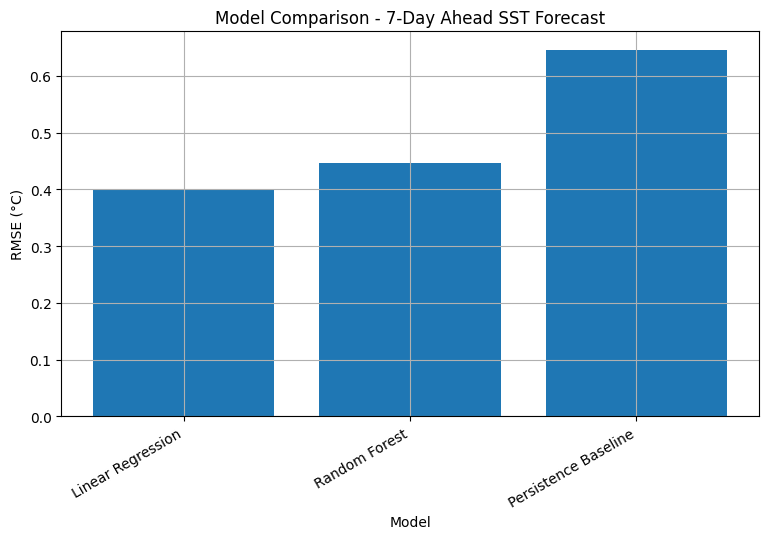

In [12]:
# 绘制模型 RMSE 对比
plt.figure(figsize=(9, 5))
plt.bar(metrics["model"], metrics["rmse"])
plt.title("Model Comparison - 7-Day Ahead SST Forecast")
plt.xlabel("Model")
plt.ylabel("RMSE (°C)")
plt.xticks(rotation=30, ha="right")
plt.grid(True)
plt.show()


In [13]:
# 构建预测结果表
predictions = test_df[["date", "sst", target_col]].copy()
predictions = predictions.rename(
    columns={"sst": "current_sst", target_col: "actual_7d_ahead_sst"}
)

predictions["persistence_pred"] = baseline_pred
predictions["linear_regression_pred"] = linear_pred
predictions["random_forest_pred"] = rf_pred

if xgb_pred is not None:
    predictions["xgboost_pred"] = xgb_pred

predictions.head()


,date,current_sst,actual_7d_ahead_sst,persistence_pred,linear_regression_pred,random_forest_pred
1630,2018-01-01,15.454437,15.615653,15.317741,15.484311,15.308291
1631,2018-01-02,15.525194,15.473968,15.317109,15.417024,15.289818
1632,2018-01-03,15.595161,15.367568,15.324701,15.513463,15.223178
1633,2018-01-04,15.587317,15.320391,15.358096,15.556954,15.474424
1634,2018-01-05,15.586972,15.550974,15.454265,15.515398,15.487088


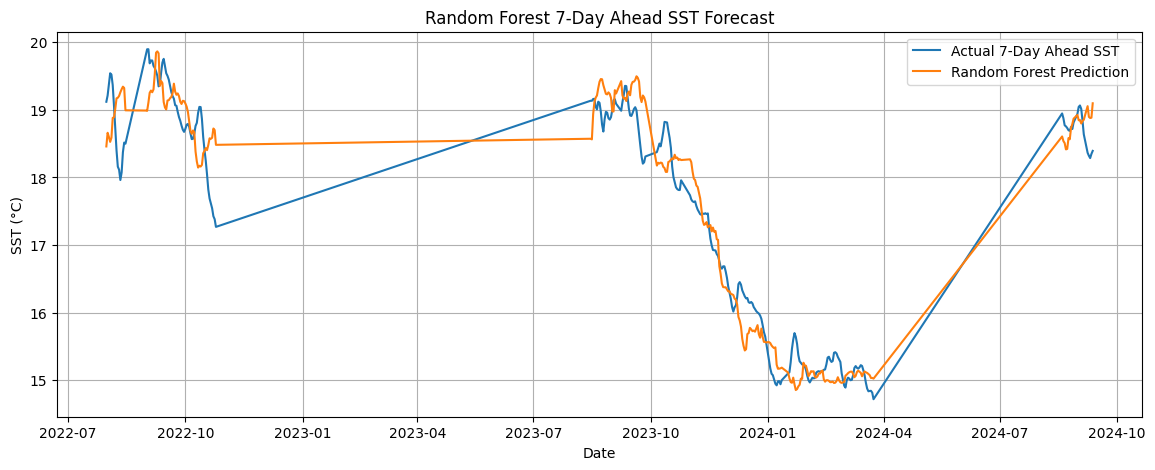

In [14]:
# Random Forest
plot_start = "2022-01-01"
plot_end = "2024-12-31"

plot_df = predictions[
    (predictions["date"] >= plot_start) & (predictions["date"] <= plot_end)
].copy()

plt.figure(figsize=(14, 5))
plt.plot(
    plot_df["date"], plot_df["actual_7d_ahead_sst"], label="Actual 7-Day Ahead SST"
)
plt.plot(
    plot_df["date"], plot_df["random_forest_pred"], label="Random Forest Prediction"
)

plt.title("Random Forest 7-Day Ahead SST Forecast")
plt.xlabel("Date")
plt.ylabel("SST (°C)")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# 画测试集预测图：XGBoost
if xgb_pred is not None:
    plt.figure(figsize=(14, 5))
    plt.plot(
        plot_df["date"], plot_df["actual_7d_ahead_sst"], label="Actual 7-Day Ahead SST"
    )
    plt.plot(plot_df["date"], plot_df["xgboost_pred"], label="XGBoost Prediction")

    plt.title("XGBoost 7-Day Ahead SST Forecast")
    plt.xlabel("Date")
    plt.ylabel("SST (°C)")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("XGBoost prediction not available.")


XGBoost prediction not available.


In [16]:
# Feature Importance：Random Forest
rf_importance = pd.DataFrame(
    {"feature": feature_cols, "importance": rf_model.feature_importances_}
).sort_values("importance", ascending=False)

rf_importance

,feature,importance
3,sst_lag_1,0.894340
2,cos_day,0.033528
4,sst_lag_2,0.017667
9,sst_roll_mean_7,0.010599
12,oni_lag_1,0.007542
1,sin_day,0.007406
8,sst_lag_30,0.006841
10,sst_roll_mean_30,0.005008
13,sst_anomaly_lag_1,0.003840
7,sst_lag_14,0.003441


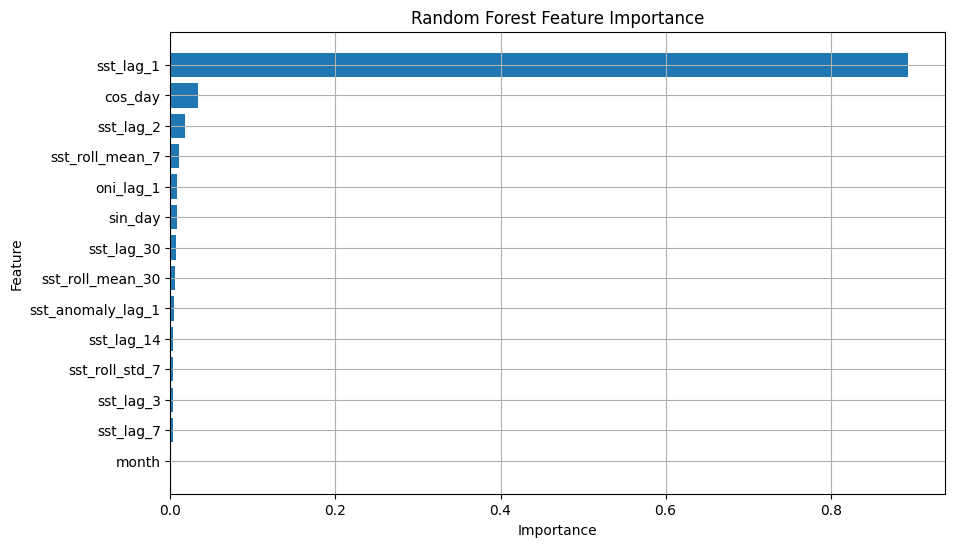

In [17]:
# 绘制 Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(rf_importance["feature"], rf_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

In [18]:
# TimeSeriesSplit CV：Random Forest
rf_cv = time_series_cv_scores(
    model_factory=lambda: train_random_forest(X_train, y_train).__class__(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    ),
    X=X_train,
    y=y_train,
    n_splits=5,
)

rf_cv

,fold,rmse,mae
0,1,0.742383,0.613457
1,2,0.479534,0.415041
2,3,0.536038,0.416786
3,4,0.610488,0.508486
4,5,0.513361,0.405730


In [19]:
metrics_path = PROCESSED_DIR / "forecast_model_metrics_1982_2024.csv"
predictions_path = PROCESSED_DIR / "forecast_predictions_1982_2024.csv"
feature_importance_path = PROCESSED_DIR / "forecast_rf_feature_importance_1982_2024.csv"
cv_path = PROCESSED_DIR / "forecast_timeseries_cv_1982_2024.csv"

metrics.to_csv(metrics_path, index=False)
predictions.to_csv(predictions_path, index=False)
rf_importance.to_csv(feature_importance_path, index=False)
rf_cv.to_csv(cv_path, index=False)

print("Saved:", metrics_path)
print("Saved:", predictions_path)
print("Saved:", feature_importance_path)
print("Saved:", cv_path)


Saved: /Users/sumi/Desktop/project/data/processed/forecast_model_metrics_1982_2024.csv
Saved: /Users/sumi/Desktop/project/data/processed/forecast_predictions_1982_2024.csv
Saved: /Users/sumi/Desktop/project/data/processed/forecast_rf_feature_importance_1982_2024.csv
Saved: /Users/sumi/Desktop/project/data/processed/forecast_timeseries_cv_1982_2024.csv
